In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# برای نمایش نمودارها به صورت درونی در Jupyter
%matplotlib inline

In [96]:
# آدرس فایل اکسل نسبت به پوشه notebooks
# دقت کنید که نام فایل دقیقاً باید مطابق با نام فایل اصلی شما باشد
file_path = "../data/LAMP 14050614 T1.xlsx"

# نام شیت شما طولانی است، پس آن را به صورت دقیق وارد می‌کنیم
sheet_name = "Sheet1"

# خواندن فایل اکسل
df = pd.read_excel(file_path, sheet_name=sheet_name)

# نمایش ۵ سطر اول برای اطمینان از درست خوانده شدن داده‌ها
display(df.head())

,t(ms),ptc,Unnamed: 2,t(s)
0,6399.137,3497,260.0,0.0
1,6399.237,3497,260.2,0.2
2,6399.337,3497,260.3,0.3
3,6399.437,3497,260.4,0.4
4,6399.537,3497,260.5,0.5


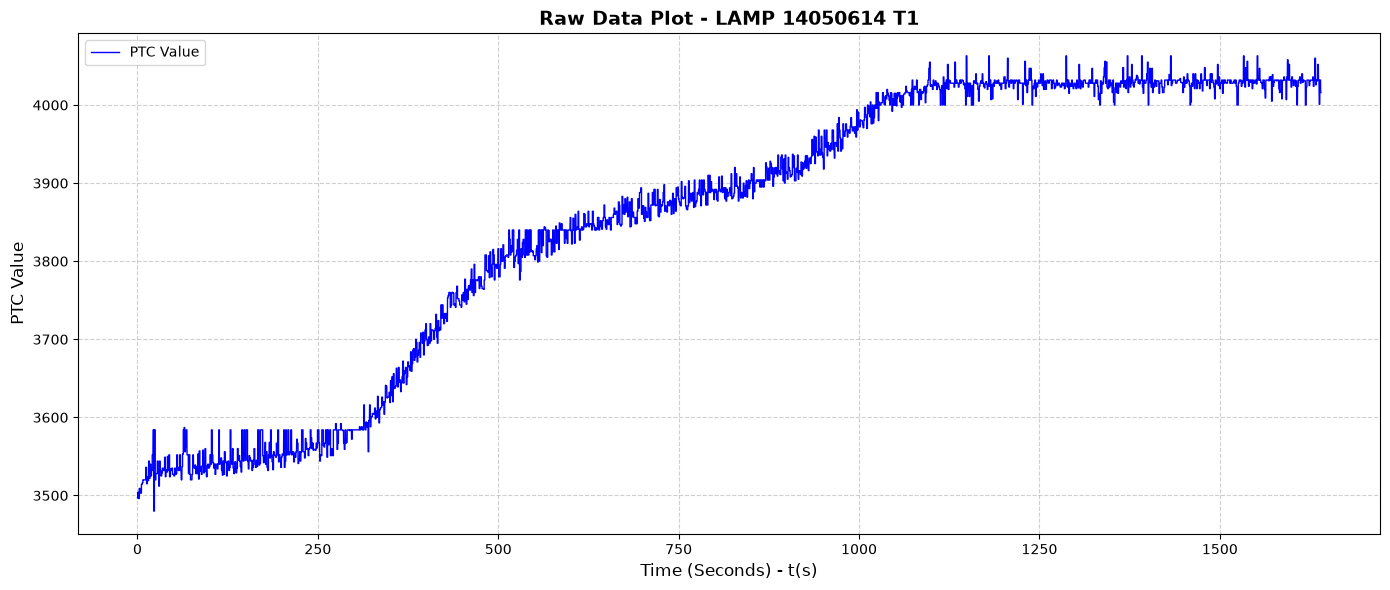

In [97]:
# تنظیمات ابعاد نمودار
plt.figure(figsize=(14, 6))

# رسم نمودار: محور X زمان به ثانیه (t(s)) و محور Y مقادیر PTC
plt.plot(df['t(s)'], df['ptc'], color='blue', linewidth=1, label='PTC Value')

# تنظیمات عنوان و برچسب‌های محورها
plt.title('Raw Data Plot - LAMP 14050614 T1', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds) - t(s)', fontsize=12)
plt.ylabel('PTC Value', fontsize=12)

# نمایش راهنما (Legend) و شبکه‌بندی (Grid)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

# نرم‌سازی محورها برای نمایش بهتر
plt.tight_layout()

# ذخیره نمودار در پوشه figures (اختیاری)
# plt.savefig("../figures/raw_data_plot.png", dpi=300)

# نمایش نمودار
plt.show()

In [98]:
import pandas as pd
import numpy as np

# 1. یافتن زمان شروع و پایان داده‌ها
min_time = df['t(s)'].min()
max_time = df['t(s)'].max()
print(max_time)

# 2. محاسبه زمان‌های هدف (هر 600 ثانیه یک‌بار)
# شروع را روی ближайний مضرب 600 تنظیم می‌کنیم (مثلاً اگر داده‌ها از 210 شروع شده باشند، اولین زمان هدف 600 خواهد بود)
start_time = int(min_time // 60) * 60
target_times = list(range(start_time, int(max_time) + 60, 60))

# 3. لیست خالی برای ذخیره نتایج
results = []

# 4. حلقه برای محاسبه میانگین هر بازه
for t_target in target_times:
    # تعریف پنجره زمانی: 0.5 ثانیه قبل تا 0.5 ثانیه بعد
    t_low = t_target - 10
    t_high = t_target + 10
    
    # فیلتر کردن داده‌ها در این پنجره زمانی 1 ثانیه‌ای
    window_df = df[(df['t(s)'] >= t_low) & (df['t(s)'] <= t_high)]
    
    # محاسبه میانگین ptc در صورت وجود داده در این بازه
    if not window_df.empty:
        mean_ptc = window_df['ptc'].mean()
        results.append({'Time (s)': t_target, 'Mean PTC': mean_ptc})

# 5. تبدیل نتایج به DataFrame
df_result = pd.DataFrame(results)

# نمایش نتایج در Jupyter
print("میانگین داده‌ها در بازه‌های 600 ثانیه‌ای:")
display(df_result)

# 6. ذخیره در فایل اکسل جدید
output_path = "../data/LAMP_14050614_T1_averages.xlsx"
df_result.to_excel(output_path, index=False)

print(f"\nفایل اکسل با موفقیت در مسیر زیر ذخیره شد:\n{output_path}")

1639.9
میانگین داده‌ها در بازه‌های 600 ثانیه‌ای:


,Time (s),Mean PTC
0,0,3509.350000
1,60,3546.325000
2,120,3543.287129
3,180,3555.287129
4,240,3562.656716
5,300,3583.099502
6,360,3645.099010
7,420,3721.702970
8,480,3782.712871
9,540,3815.089109



فایل اکسل با موفقیت در مسیر زیر ذخیره شد:
../data/LAMP_14050614_T1_averages.xlsx


In [99]:
# آدرس فایل اکسل نسبت به پوشه notebooks
# دقت کنید که نام فایل دقیقاً باید مطابق با نام فایل اصلی شما باشد
file_path = "../data/LAMP_14050614_T1_averages.xlsx"

# نام شیت شما طولانی است، پس آن را به صورت دقیق وارد می‌کنیم
sheet_name = "Sheet1"

# خواندن فایل اکسل
df = pd.read_excel(file_path, sheet_name=sheet_name)

# نمایش ۵ سطر اول برای اطمینان از درست خوانده شدن داده‌ها
display(df.head())

,Time (s),Mean PTC
0,0,3509.350000
1,60,3546.325000
2,120,3543.287129
3,180,3555.287129
4,240,3562.656716


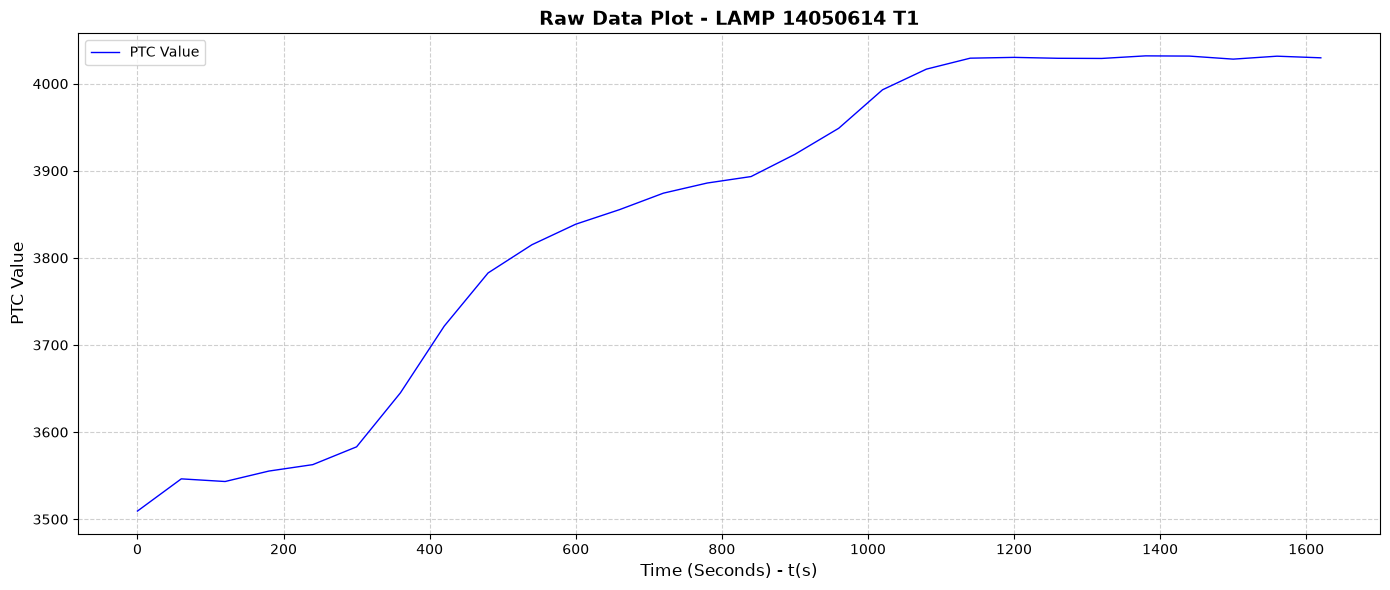

In [100]:
# تنظیمات ابعاد نمودار
plt.figure(figsize=(14, 6))

# رسم نمودار: محور X زمان به ثانیه (t(s)) و محور Y مقادیر PTC
plt.plot(df['Time (s)'], df['Mean PTC'], color='blue', linewidth=1, label='PTC Value')

# تنظیمات عنوان و برچسب‌های محورها
plt.title('Raw Data Plot - LAMP 14050614 T1', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds) - t(s)', fontsize=12)
plt.ylabel('PTC Value', fontsize=12)

# نمایش راهنما (Legend) و شبکه‌بندی (Grid)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

# نرم‌سازی محورها برای نمایش بهتر
plt.tight_layout()

# ذخیره نمودار در پوشه figures (اختیاری)
# plt.savefig("../figures/raw_data_plot.png", dpi=300)

# نمایش نمودار
plt.show()

In [101]:
# آدرس فایل اکسل نسبت به پوشه notebooks
# دقت کنید که نام فایل دقیقاً باید مطابق با نام فایل اصلی شما باشد
file_path = "../data/LAMP 14050614 T1.xlsx"

# نام شیت شما طولانی است، پس آن را به صورت دقیق وارد می‌کنیم
sheet_name = "Sheet1"

# خواندن فایل اکسل
df = pd.read_excel(file_path, sheet_name=sheet_name)

# نمایش ۵ سطر اول برای اطمینان از درست خوانده شدن داده‌ها
display(df.head())

,t(ms),ptc,Unnamed: 2,t(s)
0,6399.137,3497,260.0,0.0
1,6399.237,3497,260.2,0.2
2,6399.337,3497,260.3,0.3
3,6399.437,3497,260.4,0.4
4,6399.537,3497,260.5,0.5


In [102]:
import pandas as pd
import numpy as np

# 1. یافتن زمان شروع و پایان داده‌ها
min_time = df['t(s)'].min()
max_time = df['t(s)'].max()
print(max_time)

# 2. محاسبه زمان‌های هدف (هر 600 ثانیه یک‌بار)
# شروع را روی ближайний مضرب 600 تنظیم می‌کنیم (مثلاً اگر داده‌ها از 210 شروع شده باشند، اولین زمان هدف 600 خواهد بود)
start_time = int(min_time // 20) * 20
target_times = list(range(start_time, int(max_time) + 20, 20))

# 3. لیست خالی برای ذخیره نتایج
results = []

# 4. حلقه برای محاسبه میانگین هر بازه
for t_target in target_times:
    # تعریف پنجره زمانی: 0.5 ثانیه قبل تا 0.5 ثانیه بعد
    t_low = t_target - 0.5
    t_high = t_target + 0.5
    
    # فیلتر کردن داده‌ها در این پنجره زمانی 1 ثانیه‌ای
    window_df = df[(df['t(s)'] >= t_low) & (df['t(s)'] <= t_high)]
    
    # محاسبه میانگین ptc در صورت وجود داده در این بازه
    if not window_df.empty:
        mean_ptc = window_df['ptc'].mean()
        results.append({'Time (s)': t_target, 'Mean PTC': mean_ptc})

# 5. تبدیل نتایج به DataFrame
df_result = pd.DataFrame(results)

# نمایش نتایج در Jupyter
print("میانگین داده‌ها در بازه‌های 600 ثانیه‌ای:")
display(df_result)

# 6. ذخیره در فایل اکسل جدید
output_path = "../data/LAMP_14050614_T1_averages_20seconde.xlsx"
df_result.to_excel(output_path, index=False)

print(f"\nفایل اکسل با موفقیت در مسیر زیر ذخیره شد:\n{output_path}")

1639.9
میانگین داده‌ها در بازه‌های 600 ثانیه‌ای:


,Time (s),Mean PTC
0,0,3498.166667
1,20,3533.818182
2,40,3532.000000
3,60,3533.818182
4,80,3538.636364
...,...,...
78,1560,4031.000000
79,1580,4031.916667
80,1600,4034.818182
81,1620,4020.909091



فایل اکسل با موفقیت در مسیر زیر ذخیره شد:
../data/LAMP_14050614_T1_averages_20seconde.xlsx


In [103]:
# دقت کنید که نام فایل دقیقاً باید مطابق با نام فایل اصلی شما باشد
file_path = "../data/LAMP_14050614_T1_averages_20seconde.xlsx"

# نام شیت شما طولانی است، پس آن را به صورت دقیق وارد می‌کنیم
sheet_name = "Sheet1"

# خواندن فایل اکسل
df = pd.read_excel(file_path, sheet_name=sheet_name)

# نمایش ۵ سطر اول برای اطمینان از درست خوانده شدن داده‌ها
display(df.head())

,Time (s),Mean PTC
0,0,3498.166667
1,20,3533.818182
2,40,3532.000000
3,60,3533.818182
4,80,3538.636364


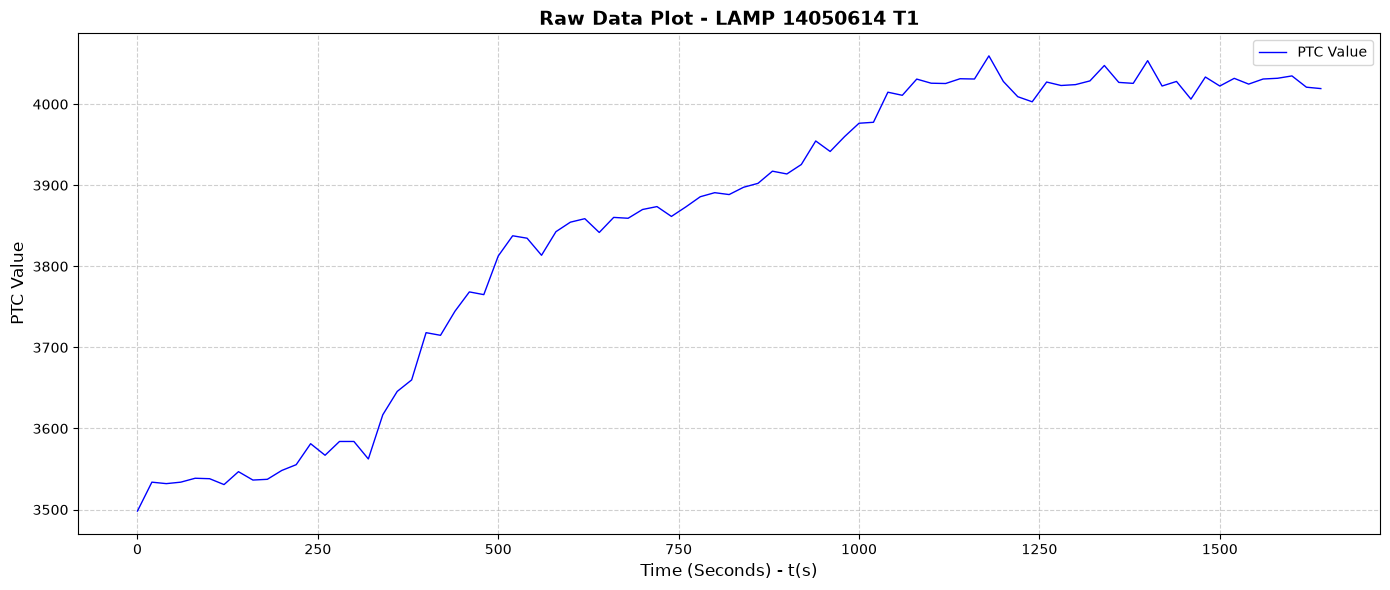

In [104]:
# تنظیمات ابعاد نمودار
plt.figure(figsize=(14, 6))

# رسم نمودار: محور X زمان به ثانیه (t(s)) و محور Y مقادیر PTC
plt.plot(df['Time (s)'], df['Mean PTC'], color='blue', linewidth=1, label='PTC Value')

# تنظیمات عنوان و برچسب‌های محورها
plt.title('Raw Data Plot - LAMP 14050614 T1', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds) - t(s)', fontsize=12)
plt.ylabel('PTC Value', fontsize=12)

# نمایش راهنما (Legend) و شبکه‌بندی (Grid)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)

# نرم‌سازی محورها برای نمایش بهتر
plt.tight_layout()

# ذخیره نمودار در پوشه figures (اختیاری)
# plt.savefig("../figures/raw_data_plot.png", dpi=300)

# نمایش نمودار
plt.show()